In [ ]:
'''
Assignment Name : Customer Segmentation
Description : Perform K-Means clustering on a mall dataset and describe customer groups.
'''

In [1]:
"""
Code 1: Generate Mall Customer Dataset
Creates a realistic mall customer dataset and saves it as CSV.
"""

import pandas as pd
import numpy as np

np.random.seed(42)
n = 200

# Define customer clusters manually
cluster_profiles = [
    {"n": 40, "age": (20, 5),  "income": (25, 5),  "score": (75, 10)},  # Young, low income, high spender
    {"n": 40, "age": (45, 8),  "income": (75, 10), "score": (20, 8)},   # Middle-aged, high income, low spender
    {"n": 40, "age": (35, 6),  "income": (55, 8),  "score": (55, 10)},  # Average customers
    {"n": 40, "age": (50, 7),  "income": (85, 8),  "score": (80, 10)},  # Wealthy high spenders
    {"n": 40, "age": (25, 5),  "income": (20, 5),  "score": (20, 8)},   # Young, low income, low spender
]

records = []
customer_id = 1

for profile in cluster_profiles:
    for _ in range(profile["n"]):
        age    = int(np.clip(np.random.normal(*profile["age"]),   18, 70))
        income = int(np.clip(np.random.normal(*profile["income"]), 10, 120))
        score  = int(np.clip(np.random.normal(*profile["score"]),   1, 100))
        gender = np.random.choice(["Male", "Female"])
        records.append([customer_id, gender, age, income, score])
        customer_id += 1

df = pd.DataFrame(records, columns=[
    "CustomerID", "Gender", "Age",
    "Annual_Income_k$", "Spending_Score"
])

df = df.sample(frac=1, random_state=42).reset_index(drop=True)  # Shuffle rows
df.to_csv("mall_customers.csv", index=False)

print("Dataset created: mall_customers.csv")
print(df.head(10).to_string(index=False))
print(f"\nShape: {df.shape}")
print(df.describe())

Dataset created: mall_customers.csv
 CustomerID Gender  Age  Annual_Income_k$  Spending_Score
         96   Male   32                43              57
         16 Female   20                15              61
         31   Male   22                24              77
        159   Male   46                82              64
        129 Female   41                68              77
        116 Female   34                45              56
         70 Female   53                84              15
        171 Female   23                26              14
        175   Male   25                22              13
         46 Female   34                76              20

Shape: (200, 5)
       CustomerID         Age  Annual_Income_k$  Spending_Score
count  200.000000  200.000000        200.000000      200.000000
mean   100.500000   35.705000         50.965000       49.730000
std     57.879185   13.157644         26.296603       27.417067
min      1.000000   18.000000         10.000000      

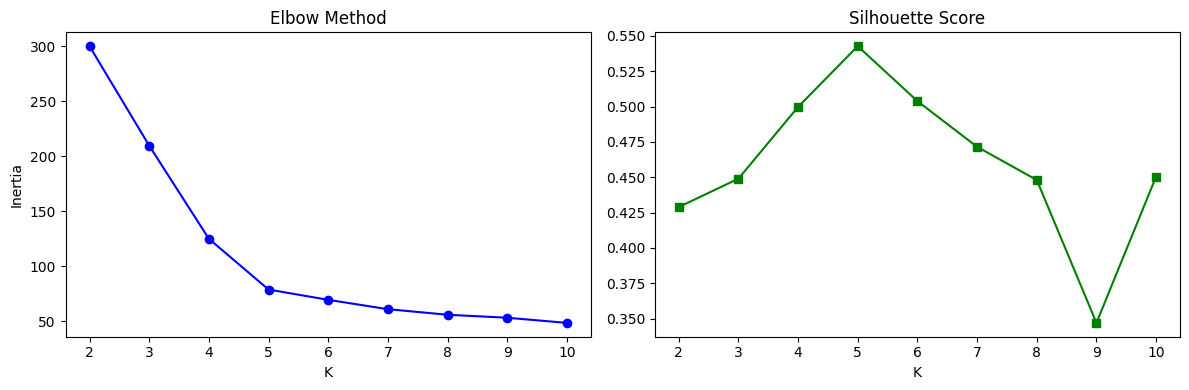

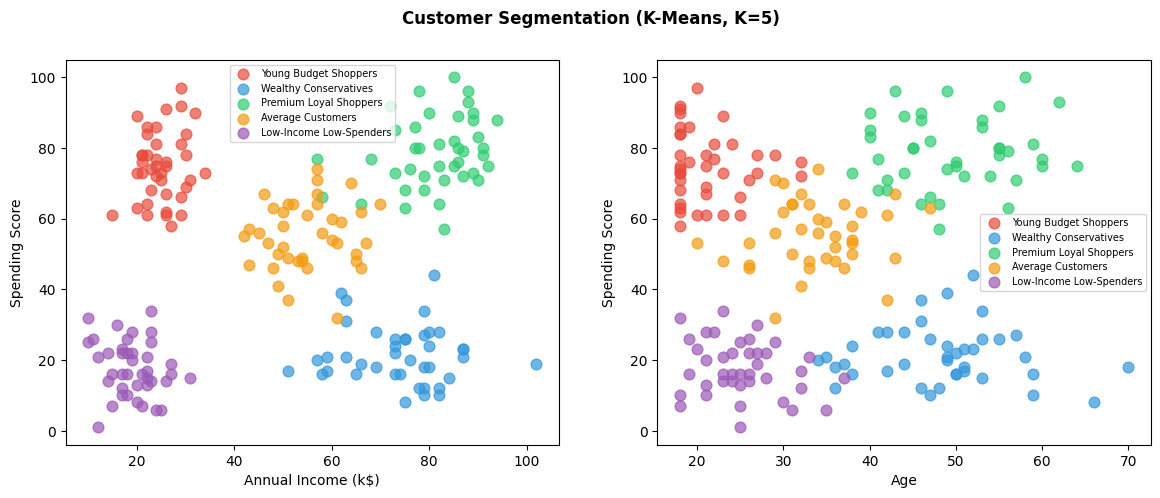

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
df = pd.read_csv("mall_customers.csv")
features = ["Age", "Annual_Income_k$", "Spending_Score"]
X_scaled = StandardScaler().fit_transform(df[features])
inertia, sil = [], []
for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)
    sil.append(silhouette_score(X_scaled, km.labels_))
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(range(2, 11), inertia, 'bo-')
axes[0].set_title("Elbow Method")
axes[0].set_xlabel("K")
axes[0].set_ylabel("Inertia")
axes[1].plot(range(2, 11), sil, 'gs-')
axes[1].set_title("Silhouette Score")
axes[1].set_xlabel("K")
plt.tight_layout()
plt.savefig("elbow.png", dpi=150)
plt.show()
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df["Cluster"] = kmeans.fit_predict(X_scaled)
means = df.groupby("Cluster")[["Annual_Income_k$", "Spending_Score"]].mean()
sorted_idx = means.sort_values(["Spending_Score", "Annual_Income_k$"]).index
labels = dict(zip(sorted_idx, ["Low-Income Low-Spenders", "Wealthy Conservatives","Average Customers", "Young Budget Shoppers", "Premium Loyal Shoppers"]))
df["Segment"] = df["Cluster"].map(labels)
COLORS = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Customer Segmentation (K-Means, K=5)", fontweight='bold')
for c in range(5):
    m = df["Cluster"] == c
    axes[0].scatter(df[m]["Annual_Income_k$"], df[m]["Spending_Score"], c=COLORS[c], s=60, alpha=0.7, label=labels[c])
    axes[1].scatter(df[m]["Age"], df[m]["Spending_Score"], c=COLORS[c], s=60, alpha=0.7, label=labels[c])
for ax, xlabel in zip(axes, ["Annual Income (k$)", "Age"]):
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Spending Score")
    ax.legend(fontsize=7)
plt.show()